In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential, layers
from tensorflow.keras.layers import Dense, LSTM, Dropout, Bidirectional, Input, Conv1D, SimpleRNN, GRU
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.losses import MeanSquaredError as MSELoss
from tensorflow.keras.metrics import MeanAbsolutePercentageError as MAPEMetrics
from tensorflow.keras.metrics import MeanAbsoluteError as MAEMetrics
from tensorflow.keras.metrics import MeanSquaredError as MSEMetrics
tfk = tf.keras
tf.keras.backend.set_floatx("float32")
from tensorflow.keras.utils import timeseries_dataset_from_array as TDFA
import tensorflow_addons as tfa

import numpy as np
from scipy import stats
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer, KNNImputer
from statsmodels.tsa.seasonal import STL
from tools.preprocess_lib import * #library bang kris

import matplotlib.pyplot as plt
from matplotlib.ticker import (AutoMinorLocator, MultipleLocator)
#from datetime import datetime
import pandas as pd
import time
import csv
import os
import seaborn as sns
import pickle 

TRAIN_NAME = 'GRU_singleDense'

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
print("Num GPUs Available: ", len(gpus))

Num GPUs Available:  1


In [2]:
LISTFILEINPUT = ['Seoul', 'Gangwon', 'Daejeon', 'Chungcheongnam-do', 'Sejong', 'Chungbuk', 'Incheon', 'Gyeonggi', 'Gwangju', 'Jeonnam', 'Jeonbuk', 'Busan', 'Gyeongnam', 'Ulsan', 'Jeju', 'Daegu', 'Gyeongbuk']

# for mixed testing choose busan

FILEINPUT = 'Busan'
DATA_PATH = f'./pickle/ready/'
DATA_NAME = f'df_final_{FILEINPUT}.pkl'

df_data = pd.read_pickle(DATA_PATH + DATA_NAME)

In [3]:
df_data.head()

,ta,ws,ss,ssQcflg,hm,P(kWh)
0,-0.512821,-0.587879,-1.0,1.0,-0.023256,-1.0
1,-0.555556,-0.721212,-1.0,1.0,0.093023,-1.0
2,-0.581197,-0.903030,-1.0,1.0,0.255814,-1.0
3,-0.602564,-0.757576,-1.0,1.0,0.162791,-1.0
4,-0.636752,-0.854545,-1.0,1.0,0.093023,-1.0


In [4]:
# for columns in df_data:
#     inspectData(df_data[columns])

In [5]:
df_data.std()

ta         0.364008
ws         0.213113
ss         0.818685
ssQcflg    0.995666
hm         0.454200
P(kWh)     0.548558
dtype: float64

In [6]:
np_data = df_data.to_numpy()

In [7]:
print(np_data.std(), np_data.mean())

0.7173668272695191 -0.23847698434304015


In [8]:
VAL_LENGTH = 0.2
LABELS_LENGTH = (24*7*4)+(24*7) #1month
SEQ_LENGTH = 24*7 #1week
DATA_FEATURES = 6
BATCH_SIZE = 32

MIU = 1e-3
EPOCH = 200
VAL_LENGTH = 0.2

In [9]:
train_size = int((len(df_data)-LABELS_LENGTH) * (1-VAL_LENGTH))
val_size = int((len(df_data) - LABELS_LENGTH) - train_size)
print('\nData length: ', len(df_data), '\nTrain data size: ', train_size, '\nVal data size: ', val_size)

# VARIANT 1
df_train = pd.DataFrame(df_data.iloc[0:train_size, :])
df_valid = pd.DataFrame(df_data.iloc[train_size:train_size+val_size, :])
df_test = pd.DataFrame(df_data.iloc[train_size+val_size:, :])


# VARIANT 2
# df_train = pd.DataFrame(df_data.iloc[0:train_size, :])
# df_test = pd.DataFrame(df_data.iloc[train_size:train_size+val_size, :])
# df_valid = pd.DataFrame(df_data.iloc[train_size+val_size:, :])

# VARIANT 3
# df_test = pd.DataFrame(df_data.iloc[0:val_size, :])
# df_train = pd.DataFrame(df_data.iloc[val_size:train_size+val_size, :])
# df_valid = pd.DataFrame(df_data.iloc[train_size+val_size:, :])



print('\nData length: ', len(df_train), '\nData head: ', df_train.head(), '\nData tail: ', df_train.tail())
print('\nData length: ', len(df_valid), '\nData head: ', df_valid.head(), '\nData tail: ', df_valid.tail())


Data length:  8760 
Train data size:  6336 
Val data size:  1584

Data length:  6336 
Data head:           ta        ws   ss  ssQcflg        hm  P(kWh)
0 -0.512821 -0.587879 -1.0      1.0 -0.023256    -1.0
1 -0.555556 -0.721212 -1.0      1.0  0.093023    -1.0
2 -0.581197 -0.903030 -1.0      1.0  0.255814    -1.0
3 -0.602564 -0.757576 -1.0      1.0  0.162791    -1.0
4 -0.636752 -0.854545 -1.0      1.0  0.093023    -1.0 
Data tail:              ta        ws   ss  ssQcflg        hm  P(kWh)
6331  0.491453 -0.636364 -1.0     -1.0  0.813953    -1.0
6332  0.461538 -0.478788 -1.0      1.0  0.837209    -1.0
6333  0.461538 -0.539394 -1.0      1.0  0.837209    -1.0
6334  0.448718 -0.369697 -1.0      1.0  0.813953    -1.0
6335  0.440171 -0.454545 -1.0      1.0  0.813953    -1.0

Data length:  1584 
Data head:              ta        ws   ss  ssQcflg        hm  P(kWh)
6336  0.435897 -0.575758 -1.0      1.0  0.813953    -1.0
6337  0.452991 -0.745455 -1.0      1.0  0.744186    -1.0
6338  0.440171 -0.

In [10]:
np_train = df_train.to_numpy()
np_valid = df_valid.to_numpy()
np_test = df_test.to_numpy()

X_train, y_train = create_dataset(np_train,np_train[:,5],SEQ_LENGTH)
X_valid, y_valid = create_dataset(np_valid,np_valid[:,5],SEQ_LENGTH)
X_test, y_test = create_dataset(np_test,np_test[:,5],SEQ_LENGTH)

In [11]:
print(X_train.shape)
print(y_train.shape)
print(X_valid.shape)
print(y_valid.shape)
print(X_test.shape)
print(y_test.shape)

(6168, 168, 6)
(6168,)
(1416, 168, 6)
(1416,)
(672, 168, 6)
(672,)


In [12]:
from tensorflow.keras.layers import GRU

def create_model(units):
    model = Sequential()
    model.add(Input(shape=(SEQ_LENGTH, DATA_FEATURES)))
    model.add(Bidirectional(LSTM(units = units*2, return_sequences=True)))
    model.add(Bidirectional(LSTM(units = units*4, return_sequences=False)))
    model.add(Dense(units=1,activation='tanh'))
    return model

model_build_stacked_bilstm = create_model(SEQ_LENGTH)

def create_model(units):
    model = Sequential()
    model.add(Input(shape=(SEQ_LENGTH, DATA_FEATURES)))
    model.add(Bidirectional(LSTM(units = units*2, return_sequences=False)))
    model.add(Dense(units=1,activation='tanh'))
    return model

model_build_bilstm = create_model(SEQ_LENGTH)

def create_model(units):
    model = Sequential()
    model.add(Input(shape=(SEQ_LENGTH, DATA_FEATURES)))
    model.add(LSTM(units = units*2, return_sequences=False))
    model.add(Dense(units=1,activation='tanh'))
    return model

model_build_lstm = create_model(SEQ_LENGTH)

def create_model(units):
    model = Sequential()
    model.add(Input(shape=(SEQ_LENGTH, DATA_FEATURES)))
    model.add(SimpleRNN(units = units*2, return_sequences=False))
    model.add(Dense(units=1,activation='tanh'))
    return model

model_build_rnn = create_model(SEQ_LENGTH)

def create_model(units):
    model = Sequential()
    model.add(Input(shape=(SEQ_LENGTH, DATA_FEATURES)))
    model.add(GRU(units = units*2, return_sequences=False))
    model.add(Dense(units=1,activation='tanh'))
    return model

model_build_gru = create_model(SEQ_LENGTH)

In [13]:
# model_build_stacked_bilstm.summary()

In [14]:
IMG_PATH = f'train_loss_plot/mixed/'
st_time1 = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

TRAIN_NAME1 = 'Stacked_BiLSTM_singleDense'
TRAIN_NAME2 = 'BiLSTM_singleDense'
TRAIN_NAME3 = 'LSTM_singleDense'
TRAIN_NAME4 = 'RNN_singleDense'
TRAIN_NAME5 = 'GRU_singleDense'

In [15]:
checkpoint_path1 = f'checkpoint/{DATA_NAME}/{TRAIN_NAME1}/' + TRAIN_NAME1 + '_' + DATA_NAME
checkpoint_path2 = f'checkpoint/{DATA_NAME}/{TRAIN_NAME2}/' + TRAIN_NAME2 + '_' + DATA_NAME
checkpoint_path3 = f'checkpoint/{DATA_NAME}/{TRAIN_NAME3}/' + TRAIN_NAME3 + '_' + DATA_NAME
checkpoint_path4 = f'checkpoint/{DATA_NAME}/{TRAIN_NAME4}/' + TRAIN_NAME4 + '_' + DATA_NAME
checkpoint_path5 = f'checkpoint/{DATA_NAME}/{TRAIN_NAME5}/' + TRAIN_NAME5 + '_' + DATA_NAME

In [16]:
model_build_stacked_bilstm.load_weights(checkpoint_path1)
model_build_bilstm.load_weights(checkpoint_path2)
model_build_lstm.load_weights(checkpoint_path3)
model_build_rnn.load_weights(checkpoint_path4)
model_build_gru.load_weights(checkpoint_path5)

In [17]:
prediction1 = model_build_stacked_bilstm.predict(X_test)
prediction2 = model_build_bilstm.predict(X_test)
prediction3 = model_build_lstm.predict(X_test)
prediction4 = model_build_rnn.predict(X_test)
prediction5 = model_build_gru.predict(X_test)

21/21 [==============================] - 0s 10ms/step


In [18]:
print(prediction1.shape, prediction2.shape, prediction3.shape, prediction4.shape, prediction5.shape)

(672, 1) (672, 1) (672, 1) (672, 1) (672, 1)


In [19]:
# # sub region of the original image
#     x1, x2, y1, y2 = 10, 15, 0, 1
#     axins.set_xlim(x1, x2)
#     axins.set_ylim(y1, y2)
#     axins.set_xticklabels([])
#     axins.set_yticklabels([])

#     ax.indicate_inset_zoom(axins, edgecolor="black")


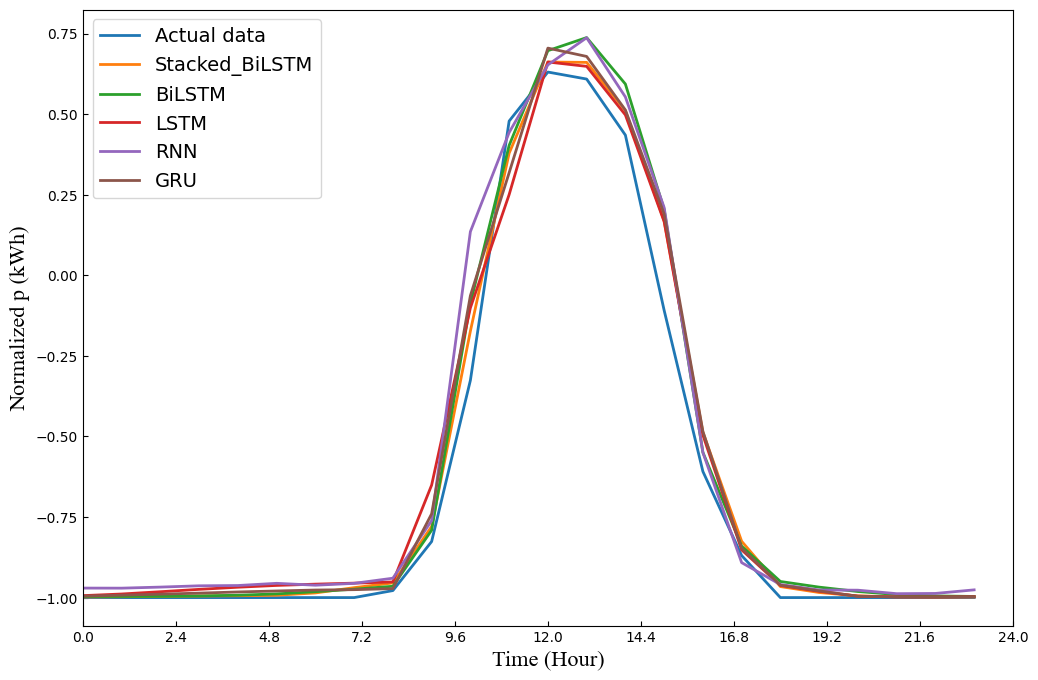

In [20]:
def plot_future():
    fig, ax= plt.subplots(figsize = (12, 8))
    ax.set_xlim(0, y_test[:24].shape[0])
#     ax.set_ylim(0, 1)
    ax.tick_params(axis="y",direction="in")
    ax.tick_params(axis="x",direction="in")
    ax.xaxis.set_major_locator(MultipleLocator(0.1*y_test[:24].shape[0]))
#     ax.yaxis.set_major_locator(MultipleLocator(.2)
#     x1, x2, y1, y2 = 10, 15, 0, 1
#     ax.set_xlim(x1, x2)
#     ax.set_ylim(y1, y2)
#     ax.set_xticklabels([])
#     ax.set_yticklabels([])
#     ax.indicate_inset_zoom(ax, edgecolor="black")
    csfont = {'fontname':'Times New Roman'}
    range_future = len(prediction1[:24])
    plt.plot(np.arange(range_future), np.array(y_test[:24]),  label='Actual data',linewidth=2)
    plt.plot(np.arange(range_future),np.array(prediction1[:24]),label='Stacked_BiLSTM',linewidth=2)
    plt.plot(np.arange(range_future),np.array(prediction2[:24]),label='BiLSTM',linewidth=2)
    plt.plot(np.arange(range_future),np.array(prediction3[:24]),label='LSTM',linewidth=2)
    plt.plot(np.arange(range_future),np.array(prediction4[:24]),label='RNN',linewidth=2)
    plt.plot(np.arange(range_future),np.array(prediction5[:24]),label='GRU',linewidth=2)
    plt.legend(loc='upper left',fontsize=14)
    plt.xlabel('Time (Hour)',fontsize=16,**csfont)
    plt.ylabel('Normalized p (kWh)',fontsize=16,**csfont)
    plt.savefig(IMG_PATH + 'MIXED_PREDICTION RESULT_' + DATA_NAME +'.jpg')
    bot.send_image(IMG_PATH + 'MIXED_PREDICTION RESULT_' + DATA_NAME  +'.jpg', caption='PREDICTION PLOT ' + DATA_NAME)

plot_future()

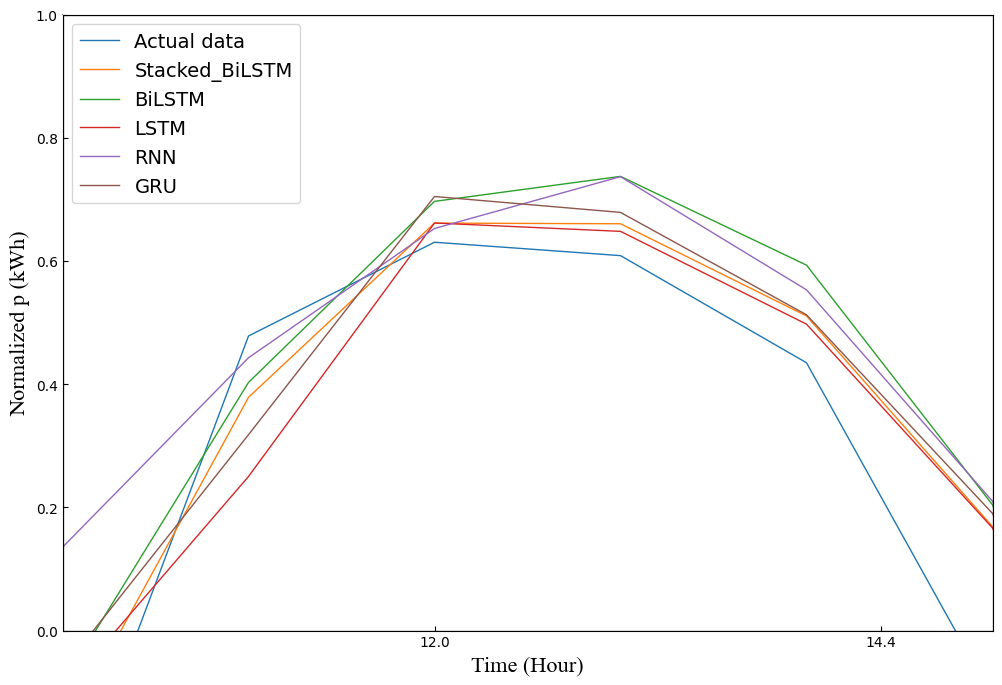

In [21]:
def plot_future():
    fig, ax= plt.subplots(figsize = (12, 8))
    ax.set_xlim(0, y_test[:24].shape[0])
#     ax.set_ylim(0, 1)
    ax.tick_params(axis="y",direction="in")
    ax.tick_params(axis="x",direction="in")
    ax.xaxis.set_major_locator(MultipleLocator(0.1*y_test[:24].shape[0]))
#     ax.yaxis.set_major_locator(MultipleLocator(.2)
    x1, x2, y1, y2 = 10, 15, 0, 1
    ax.set_xlim(x1, x2)
    ax.set_ylim(y1, y2)
    ax.indicate_inset_zoom(ax, edgecolor="black")
    csfont = {'fontname':'Times New Roman'}
    range_future = len(prediction1[:24])
    plt.plot(np.arange(range_future), np.array(y_test[:24]),  label='Actual data',linewidth=1)
    plt.plot(np.arange(range_future),np.array(prediction1[:24]),label='Stacked_BiLSTM',linewidth=1)
    plt.plot(np.arange(range_future),np.array(prediction2[:24]),label='BiLSTM',linewidth=1)
    plt.plot(np.arange(range_future),np.array(prediction3[:24]),label='LSTM',linewidth=1)
    plt.plot(np.arange(range_future),np.array(prediction4[:24]),label='RNN',linewidth=1)
    plt.plot(np.arange(range_future),np.array(prediction5[:24]),label='GRU',linewidth=1)
    plt.legend(loc='upper left',fontsize=14)
    plt.xlabel('Time (Hour)',fontsize=16,**csfont)
    plt.ylabel('Normalized p (kWh)',fontsize=16,**csfont)
    plt.savefig(IMG_PATH + 'MIXED_PREDICTION RESULT_' + DATA_NAME +'.jpg')
    bot.send_image(IMG_PATH + 'MIXED_PREDICTION RESULT_' + DATA_NAME  +'.jpg', caption='ZOOM IN PREDICTION PLOT ' + DATA_NAME)

plot_future()

In [22]:
from sklearn.metrics import r2_score
def smapeCalc(A, F):
    return 100/len(A) * np.sum(np.abs(F - A) / ((np.abs(A) + np.abs(F))/2))

def evaluate_prediction(predictions, actual, model_name):
    # dif=predictions-actual
    # errors = np.nan_to_num(dif, nan=0)
    # mse = np.square(errors).mean()*100
    # rmse = np.sqrt(mse)*100
    # mae = np.abs(errors).mean()
    # mape = np.abs(errors).mean()*100
    mse = mean_squared_error(predictions,actual)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(predictions,actual)
    smape = smapeCalc(predictions,actual)
    mape = mean_absolute_percentage_error(predictions,actual)
    r2=r2_score(predictions,actual)
    print(model_name + ':')
    print('Mean Square Error (MSE): {:.4f}'.format(mse))
    print('Root Mean Square Error (NRMSE): {:.4f}'.format(rmse))
    print('Mean Absolute Error (MAE): {:.4f}'.format(mae))
    print('Symmetric Mean Absolute Percentage Error (SMAPE): {:.4f}'.format(smape))
    print('Mean Absolute Percentage Error (MAPE): {:.4f}'.format(mape))
    print('Coefficient of determination (R2): {:.4f}'.format(r2))
    return smape, mse, rmse, mae, mape, r2

smape, mse, rmse, mae, mape, r2 = evaluate_prediction(prediction2, y_test, TRAIN_NAME)

GRU_singleDense:
Mean Square Error (MSE): 0.0143
Root Mean Square Error (NRMSE): 0.1196
Mean Absolute Error (MAE): 0.0612
Symmetric Mean Absolute Percentage Error (SMAPE): 52223.0681
Mean Absolute Percentage Error (MAPE): 0.2532
Coefficient of determination (R2): 0.9549


In [23]:
tele_messages = {
        'PREDICTION TEST RESULT': TRAIN_NAME2,
        'Train Name': TRAIN_NAME2,
        'Input Data': DATA_NAME,
        'MSE': mse,
        'MAE': mae,
        'MAPE': mape,
        'R Square': r2,
        'RMSE': rmse,
    }

print(tele_messages)

bot.send_message(tele_messages)

{'PREDICTION TEST RESULT': 'BiLSTM_singleDense', 'Train Name': 'BiLSTM_singleDense', 'Input Data': 'df_final_Busan.pkl', 'MSE': 0.01431388782101129, 'MAE': 0.061161649100736515, 'MAPE': 0.25323625151220686, 'R Square': 0.954895282022536, 'RMSE': 0.1196406612361002}
